In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


In [5]:
data ={
'Age': [25, 45, 35, 50, 23, 40, 60, 48, 22, 33],
    'Annual_Spend': [1000, 5000, 1500, 7000, 500, 4500, 8000, 5200, 1200, 2000],
    'Subscribed': [0, 1, 0, 1, 0, 1, 1, 1, 0, 0]   
}

df = pd.DataFrame(data)
df

,Age,Annual_Spend,Subscribed
0,25,1000,0
1,45,5000,1
2,35,1500,0
3,50,7000,1
4,23,500,0
5,40,4500,1
6,60,8000,1
7,48,5200,1
8,22,1200,0
9,33,2000,0


In [6]:
X=df[['Age','Annual_Spend']]
y=df.Subscribed.values

In [10]:
clf = DecisionTreeClassifier(criterion="entropy",max_depth=3)
clf.fit(X,y)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [11]:
new_customer=[[38,3000]]
clf.predict(new_customer)

array([0])

1. The Complex Scenario: Loan Underwriting
We have a dataset of 1,000 applicants with the following "Messy" features:

Income: Continuous numerical data.

Credit Score: Continuous numerical data.

Employment Years: Discrete numerical data.

Prior Defaults: Categorical (0 or 1).

Loan Amount: Continuous numerical data.

In [14]:
np.random.seed(45)
n_samples =1000

data ={
    'Income': np.random.normal(50000, 15000, n_samples),
    'Credit_Score': np.random.normal(650, 100, n_samples),
    'Debt_Ratio': np.random.uniform(0.1, 0.6, n_samples),
    'Employment_Yrs': np.random.poisson(5, n_samples),
    'Prior_Default': np.random.choice([0, 1], n_samples, p=[0.8, 0.2])    
    
}
df= pd.DataFrame(data)
df.head(4)

,Income,Credit_Score,Debt_Ratio,Employment_Yrs,Prior_Default
0,50395.621593,697.630260,0.326842,5,1
1,53904.825521,665.647264,0.231775,2,1
2,44072.816877,725.473731,0.116463,9,1
3,46935.486424,728.863832,0.315788,4,0


In [17]:
df['Default'] = ((df['Credit_Score'] < 600) & (df['Debt_Ratio'] > 0.4) | 
                 (df['Prior_Default'] == 1) & (df['Income'] < 40000)).astype(int)

In [18]:
X = df.drop('Default',axis=1)
y= df['Default']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=34)


In [21]:
model = DecisionTreeClassifier(criterion = 'entropy',max_depth =5, min_samples_leaf =10)
model.fit(X_train,y_train)

predictions=model.predict(X_test)
predictions

array([1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0])

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score,recall_score
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
accuracy_score(model.predict(X_test),y_test)

0.985

In [27]:
confusion_matrix(model.predict(X_test),y_test)

array([[163,   3],
       [  0,  34]])

In [29]:
163/(163+3), 163/(163+0)

(0.9819277108433735, 1.0)

In [31]:
precision_score(model.predict(X_test),y_test)

0.918918918918919

In [32]:
recall_score(model.predict(X_test),y_test)

1.0

When you have an 80/20 imbalance (80% "No Default", 20% "Default"), the model is naturally biased. It sees four times more examples of safe customers than risky ones.To fix this using class_weight and min_samples_leaf, you are essentially using a "Carrot and Stick" approach: one forces the model to pay attention, and the other prevents it from getting distracted by noise.1. Using class_weight (The "Carrot")In an 80/20 split, the model treats every mistake as having a weight of "1." If it misses a "Default," it only loses 1 point of accuracy.By setting class_weight='balanced', you tell the math:"A mistake on the 20% group (Defaults) is worth 4 points.""A mistake on the 80% group (Safe) is worth 1 point."The Result: The tree is now mathematically incentivized to find the minority class. It will sacrifice a few "Safe" customers (False Positives) if it means catching those "Defaults" (True Positives).2. Tuning min_samples_leaf (The "Stick")This is where it gets tricky. When you give the minority class more weight, the Decision Tree becomes extremely sensitive.If there is one weird outlier in your data (e.g., a high-income person who defaulted because of a freak accident), the "weighted" tree will see that single person as 4 people. It will try to create a tiny, specialized branch just for them. This is Overfitting.How min_samples_leaf helps:It sets a "Minimum Population" rule.By increasing this number (e.g., min_samples_leaf=20), you tell the tree: "I don't care how much weight a group has; if there aren't at least 20 actual samples in this branch, don't make the split."3. The Combined Effect: Finding the "Sweet Spot"If you use class_weight alone, your tree looks like a jagged mountain range (very overfitted). If you tune min_samples_leaf alone, your tree might be too simple and miss the minority class entirely.Together, they create a "Broadened Perspective":Parameter ActionImpact on TreeImpact on Metricsclass_weight='balanced'Makes the tree "look harder" for Defaults.Increases Recall (catches more).min_samples_leaf=20Makes the tree ignore "weird" individual cases.Increases Generalization (works on new data).

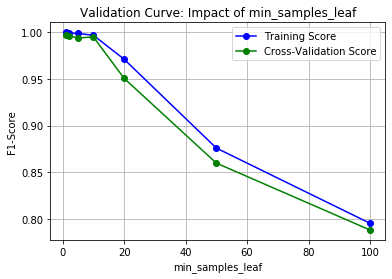

In [33]:
from sklearn.model_selection import validation_curve

# 1. Define the range of values to test
param_range = [1, 2, 5, 10, 20, 50, 100]

# 2. Calculate scores for training and cross-validation
# We use f1_weighted because it's better for our 80/20 imbalance
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(class_weight='balanced'), 
    X_train, y_train, 
    param_name="min_samples_leaf", 
    param_range=param_range,
    cv=5, 
    scoring="f1_weighted"
)

# 3. Calculate mean and standard deviation for plotting
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 4. Plot the results
plt.plot(param_range, train_mean, label="Training Score", color="blue", marker='o')
plt.plot(param_range, test_mean, label="Cross-Validation Score", color="green", marker='o')
plt.title("Validation Curve: Impact of min_samples_leaf")
plt.xlabel("min_samples_leaf")
plt.ylabel("F1-Score")
plt.legend(loc="best")
plt.grid()
plt.show()